# Adult Dataset — Certified Counterfactual Sampling

Pipeline:
1. Load a trained `TabularClassifier` from a Lightning checkpoint.
2. Embed the training set into the continuous embedding space (70-dim for Adult).
3. **K-medoids** in embedding space → select K spread-out representatives per class.
4. Build `CertCFAtlas` on `model.net` (pure ReLU MLP, LiRPA-compatible) using the K medoids per class.
5. For a query point (class 0: income ≤50K), find the nearest certified counterfactual (class 1: income >50K) in embedding space.
6. Decode back to original feature values (nearest-category for categoricals).
7. Re-embed the decoded point and verify it falls inside the certified polytope.

**Why k-medoids?** With 39k training points, random subsampling to 500/class produces dense clusters where many polytopes overlap. K-medoids selects *spread-out* representatives that tile the embedding space more uniformly — fewer polytopes, less QP work at query time, and better coverage per polytope.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import pandas as pd
from torch.utils.data import TensorDataset

from training.lit_classifier import LitClassifier
from training.datamodules.adult import AdultDataModule, _ALL_COLS, INPUT_TYPES, _CATEGORICAL, _NUMERICAL, CARDINALITIES
from models.classifiers import TabularClassifier
from certcf import CertCFAtlas

# DEVICE = 'cuda'  # atlas runs on CPU; change to 'cuda' if preferred
DEVICE = 'cpu'
CKPT  = '../checkpoints/adult_classifier/last-v3.ckpt'

## 1. Load model

In [2]:
# LitClassifier uses save_hyperparameters(ignore=["model"]), so the model architecture
# is not stored in the checkpoint — must be provided explicitly at load time.
tabular_model = TabularClassifier(
    input_types=INPUT_TYPES,
    cardinalities=CARDINALITIES,
    embedding_dim=1,
    hidden_dims=[64, 32],
    num_classes=2,
)

lit = LitClassifier.load_from_checkpoint(CKPT, model=tabular_model, map_location=DEVICE)
model = lit.model.eval().to(DEVICE)

print(f'embed_dim : {model.embed_dim}')
print(f'net       : {model.net}')

embed_dim : 14
net       : Sequential(
  (0): Linear(in_features=14, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


## 2. Load & preprocess data

In [3]:
dm = AdultDataModule(data_dir='../data/', batch_size=256, num_workers=0)
dm.setup()

X_train, y_train = dm.train_ds.tensors
X_test,  y_test  = dm.test_ds.tensors
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: torch.Size([39074, 14]), Test: torch.Size([4884, 14])


## 3. Embed training set & K-Medoids downsampling

In [4]:
with torch.no_grad():
    Z_train = model.embed(X_train.to(DEVICE)).cpu()

embedded_ds = TensorDataset(Z_train, y_train)
print(f'Embedded training set: {Z_train.shape}')

Embedded training set: torch.Size([39074, 14])


In [5]:
try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_BACKEND = 'sklearn_extra'
except ImportError:
    KMedoids = None
    KMEDOIDS_BACKEND = 'kmeans+nn'
    from sklearn.cluster import KMeans
    from sklearn.metrics import pairwise_distances

print(f'K-medoids backend: {KMEDOIDS_BACKEND}')

SEED = 42
K_PER_CLASS = 1000


def fit_kmedoids(X, k, seed=SEED):
    """Return indices of k medoids in X (actual data points nearest each cluster centre)."""
    k = min(k, len(X))
    if KMEDOIDS_BACKEND == 'sklearn_extra':
        km = KMedoids(n_clusters=k, metric='euclidean', method='alternate', random_state=seed)
        km.fit(X)
        return km.medoid_indices_
    else:
        km = KMeans(n_clusters=k, random_state=seed, n_init='auto')
        km.fit(X)
        return pairwise_distances(km.cluster_centers_, X).argmin(axis=1)


# Cluster each class independently in the 70-dim embedding space
medoid_z_list, medoid_y_list = [], []
for c in range(2):
    mask = (y_train == c).numpy()
    Z_c = Z_train[mask].numpy()
    med_idx = fit_kmedoids(Z_c, K_PER_CLASS)
    medoid_z_list.append(torch.tensor(Z_c[med_idx], dtype=torch.float32))
    medoid_y_list.append(torch.full((len(med_idx),), c, dtype=torch.long))
    print(f'  Class {c}: {mask.sum():>6d} embedded points  →  {len(med_idx)} medoids')

medoid_z_all = torch.cat(medoid_z_list)
medoid_y_all = torch.cat(medoid_y_list)
medoid_ds = TensorDataset(medoid_z_all, medoid_y_all)

print(f'\nFull embedded dataset  : {len(embedded_ds)} samples')
print(f'Medoid dataset         : {len(medoid_ds)} samples  ({100*len(medoid_ds)/len(embedded_ds):.2f}% of full)')

K-medoids backend: kmeans+nn
  Class 0:  29730 embedded points  →  1000 medoids
  Class 1:   9344 embedded points  →  1000 medoids

Full embedded dataset  : 39074 samples
Medoid dataset         : 2000 samples  (5.12% of full)


In [6]:
atlas = CertCFAtlas(model.net, medoid_ds, device=DEVICE)
atlas.build(
    eps=0.5,
    norm=1,
    batch_size=256,
)
print(atlas.summary())

Building certified atlas (eps=0.5, L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:00<00:00,  8.92it/s]

  Building BVH spatial indices...
    Class 0: 1000 polytopes, tree depth 11
    Class 1: 1000 polytopes, tree depth 11
Done! Total: 2000 polytopes across 2 classes
CertCFAtlas Summary
Classes: 2
Perturbation: eps=0.5, L1 norm
Device: cpu

  Class 0: 1000 polytopes (BVH depth 11)
  Class 1: 1000 polytopes (BVH depth 11)

Total polytopes: 2000


## 4. Pick a query point (predicted class 0: income ≤50K)

In [7]:
with torch.no_grad():
    preds_test = model(X_test.to(DEVICE)).argmax(dim=1).cpu()

# Take the first test sample the model predicts as class 0
query_idx = (preds_test == 0).nonzero(as_tuple=True)[0][0].item()
x_query = X_test[query_idx]   # (14,)
print(f'Query index: {query_idx}, true label: {y_test[query_idx].item()}, predicted: {preds_test[query_idx].item()}')

with torch.no_grad():
    z_query = model.embed(x_query.unsqueeze(0).to(DEVICE)).squeeze(0).cpu().numpy()
print(f'z_query shape: {z_query.shape}')

Query index: 0, true label: 0, predicted: 0
z_query shape: (14,)


## 5. Find counterfactual in embedding space (target: class 1, income >50K)

In [8]:
# --- Feature → embedding-dim mapping ---
print(f"{'Feature':<20} {'Type':<12} {'Emb dims'}")
print('-' * 45)
for col, t, (s, e) in zip(_ALL_COLS, INPUT_TYPES, model._slices):
    print(f'{col:<20} {t:<12} [{s}:{e}]  ({e-s} dim{"s" if e-s>1 else ""})')

# Features that should NOT change (immutable / non-actionable)
# model.feature_dims() maps names → embedding-space indices
# FIXED_FEATURES = ['race', 'sex', 'native-country', 'age']
FIXED_FEATURES = ['race', 'sex', 'native-country']
fixed_dims = model.feature_dims(FIXED_FEATURES, _ALL_COLS)
print(f'\nFixed features : {FIXED_FEATURES}')
print(f'Fixed emb dims : {fixed_dims.tolist()}  ({len(fixed_dims)} total)')

result = atlas.find_counterfactual(
    z_query, target_class=1, method='bvh',
    fixed_dims=fixed_dims,
    solver_maxiter=3000
)
print(result)

Feature              Type         Emb dims
---------------------------------------------
age                  numerical    [0:1]  (1 dim)
workclass            categorical  [1:2]  (1 dim)
fnlwgt               numerical    [2:3]  (1 dim)
education            categorical  [3:4]  (1 dim)
education-num        numerical    [4:5]  (1 dim)
marital-status       categorical  [5:6]  (1 dim)
occupation           categorical  [6:7]  (1 dim)
relationship         categorical  [7:8]  (1 dim)
race                 categorical  [8:9]  (1 dim)
sex                  categorical  [9:10]  (1 dim)
capital-gain         numerical    [10:11]  (1 dim)
capital-loss         numerical    [11:12]  (1 dim)
hours-per-week       numerical    [12:13]  (1 dim)
native-country       categorical  [13:14]  (1 dim)

Fixed features : ['race', 'sex', 'native-country']
Fixed emb dims : [8, 9, 13]  (3 total)
CounterfactualResult(x_cf=array([-0.11413002,  0.43392596,  0.04877889,  0.11596214, -0.11236437,
       -1.15859246,  0.4274

## 6. Decode back to original features

In [9]:
assert result.success, 'No counterfactual found — try increasing eps or max_samples_per_class'

z_cf = torch.tensor(result.x_cf, dtype=torch.float32).unsqueeze(0)
x_cf = model.decode(z_cf).squeeze(0)   # (14,) — categorical dims are nearest integer indices
print(f'x_cf: {x_cf}')

x_cf: tensor([-0.1141,  3.0000,  0.0488,  5.0000, -0.1124,  1.0000, 14.0000,  0.0000,
         4.0000,  1.0000, -0.2159, -0.2815,  0.7618, 27.0000])


## 7. Re-embed & verify certification

Check whether the re-embedded decoded point falls inside the certified polytope found by the atlas.

In [10]:
with torch.no_grad():
    z_cf_re = model.embed(x_cf.unsqueeze(0).to(DEVICE)).squeeze(0).cpu().numpy()

# Retrieve the anchor polytope
bd = atlas.bounds[1]
A  = bd['lA'][result.anchor_idx]     # (n_constraints, 70)
b  = bd['lbias'][result.anchor_idx]  # (n_constraints,)

margins = A @ z_cf_re + b
is_certified = bool(np.all(margins >= -1e-6))

# Also check model prediction on the decoded CF
with torch.no_grad():
    pred_cf = model(x_cf.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()

print(f'Re-embedded CF certified : {is_certified}  (min margin: {margins.min():.4f})')
print(f'Model prediction on x_cf : {pred_cf}  (expected 1)')

Re-embedded CF certified : False  (min margin: -2.6677)
Model prediction on x_cf : 0  (expected 1)


## 8. Human-readable comparison

In [11]:
def to_human_readable(x_tensor, dm):
    """Convert a raw feature tensor (14,) to a readable dict."""
    x = x_tensor.numpy()
    num_cols = [c for c in _ALL_COLS if c in _NUMERICAL]
    num_idx  = [_ALL_COLS.index(c) for c in num_cols]
    
    # Inverse-scale numerical features
    x_num_scaled = x[num_idx].reshape(1, -1)
    x_num_orig   = dm.scaler.inverse_transform(x_num_scaled)[0]
    
    row = {}
    num_iter = iter(x_num_orig)
    for col, t in zip(_ALL_COLS, INPUT_TYPES):
        i = _ALL_COLS.index(col)
        if t == 'numerical':
            row[col] = round(float(next(num_iter)), 2)
        else:
            cat_idx = int(x[i])
            row[col] = dm.label_encoders[col].classes_[cat_idx]
    return row

orig_row = to_human_readable(x_query.cpu(), dm)
cf_row   = to_human_readable(x_cf.cpu(), dm)

df = pd.DataFrame({'original': orig_row, 'counterfactual': cf_row})
df['changed'] = df['original'] != df['counterfactual']
df

,original,counterfactual,changed
age,24.0,37.11,True
workclass,Private,Private,False
fnlwgt,333505.0,194190.2,True
education,HS-grad,7th-8th,True
education-num,9.0,9.79,True
marital-status,Married-spouse-absent,Married-AF-spouse,True
occupation,Transport-moving,missing,True
relationship,Own-child,Husband,True
race,White,White,False
sex,Male,Male,False


## 9. 2D PCA visualization of the embedding space

Embedding dim  : 14
Fixed dims     : 3  [8, 9, 13]
Free dims      : 11  (used for PCA)
Background points: 3000,  misclassified: 609 (20.3%)
Polytopes projected — class 0: 985/1000, class 1: 867/1000


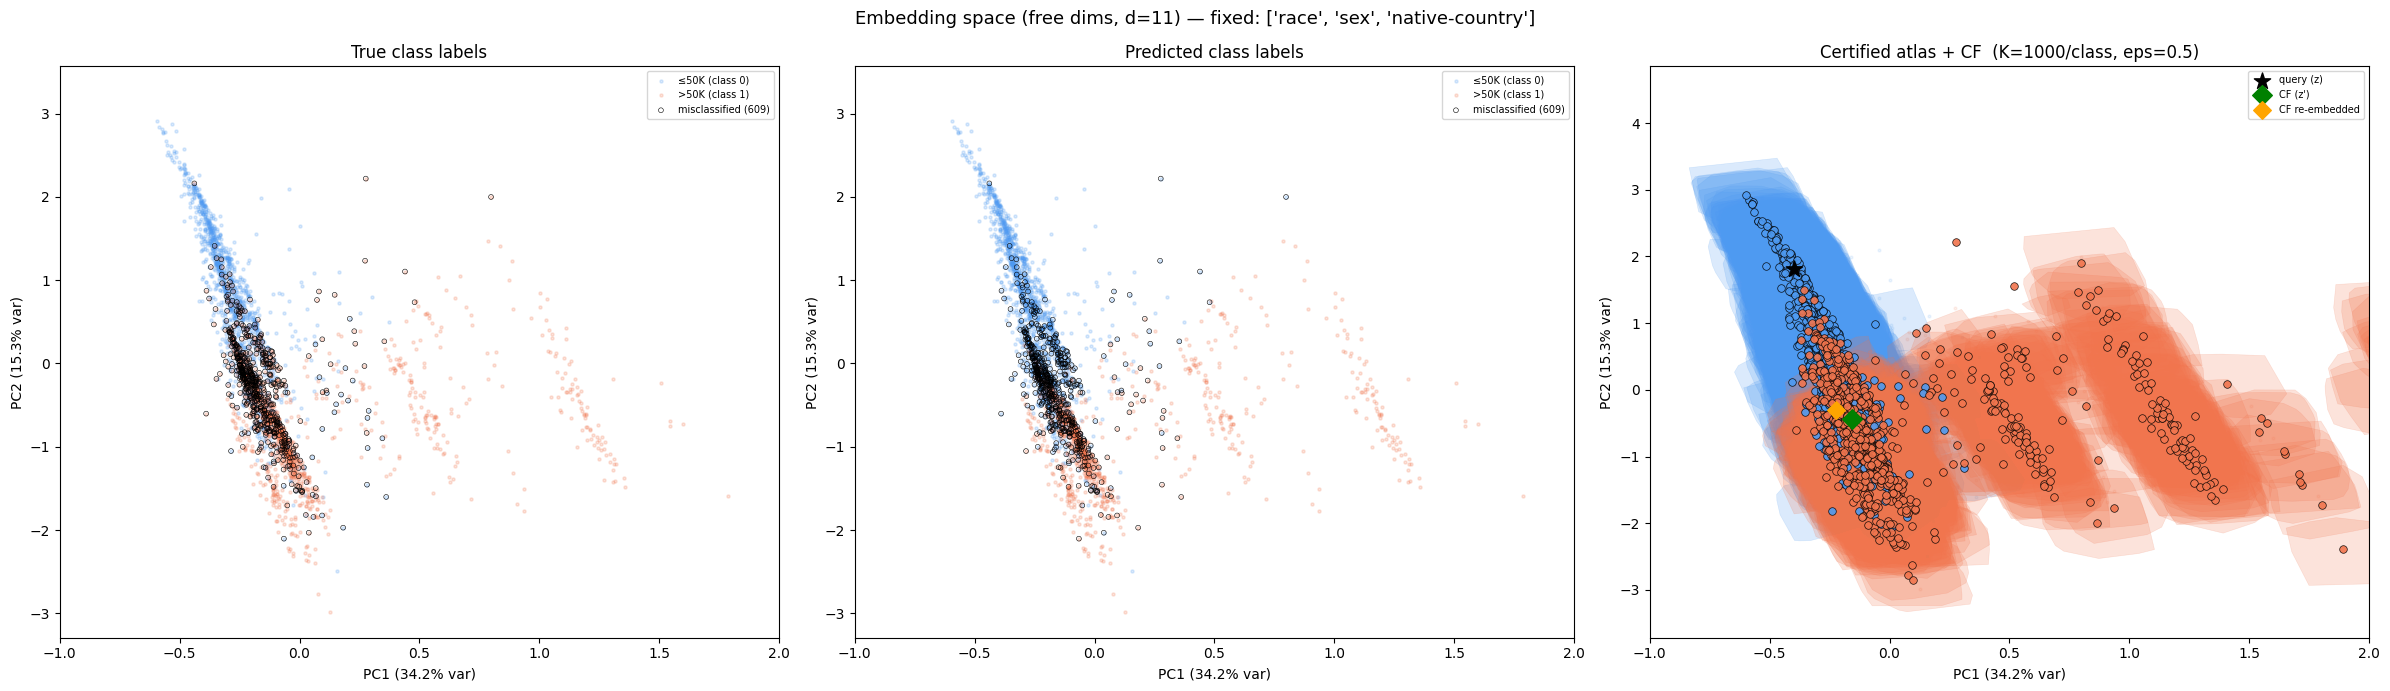

In [25]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull, QhullError
from matplotlib.patches import Polygon as MplPolygon

# Free dimensions: drop fixed ones (zero variance in constrained CF search)
free_dims = np.array([i for i in range(model.embed_dim) if i not in set(fixed_dims.tolist())])
print(f'Embedding dim  : {model.embed_dim}')
print(f'Fixed dims     : {len(fixed_dims)}  {fixed_dims.tolist()}')
print(f'Free dims      : {len(free_dims)}  (used for PCA)')

# --- Subsample background points, keep FULL embedding for predictions ---
N_PLOT = 3000
rng = np.random.default_rng(0)
idx0 = rng.choice((y_train == 0).nonzero(as_tuple=True)[0].numpy(), N_PLOT // 2, replace=False)
idx1 = rng.choice((y_train == 1).nonzero(as_tuple=True)[0].numpy(), N_PLOT // 2, replace=False)
Z_plot_full = torch.cat([Z_train[idx0], Z_train[idx1]])  # full embed, needed for predictions

y_true_plot = np.array([0] * (N_PLOT // 2) + [1] * (N_PLOT // 2))

with torch.no_grad():
    y_pred_plot = model.net(Z_plot_full.to(DEVICE)).argmax(dim=1).cpu().numpy()

n_wrong = (y_true_plot != y_pred_plot).sum()
print(f'Background points: {N_PLOT},  misclassified: {n_wrong} ({100*n_wrong/N_PLOT:.1f}%)')

# --- Fit PCA on free dims only ---
Z_plot_free = Z_plot_full.numpy()[:, free_dims]
pca = PCA(n_components=2, random_state=0, whiten=True)
Z2 = pca.fit_transform(Z_plot_free)
explained = pca.explained_variance_ratio_

# Project special points
Z2_med     = pca.transform(medoid_z_all.numpy()[:, free_dims])
z_query_2d = pca.transform(z_query[free_dims].reshape(1, -1))[0]
z_cf_2d    = pca.transform(result.x_cf[free_dims].reshape(1, -1))[0]
z_cf_re_2d = pca.transform(z_cf_re[free_dims].reshape(1, -1))[0]

# --- Project atlas polytopes to 2D (MC sampling inside eps-box + halfspace filter) ---
N_MC = 500
rng2 = np.random.default_rng(1)
polytope_hulls = {0: [], 1: []}
for cls in [0, 1]:
    bd = atlas.bounds[cls]
    for i in range(len(bd['X'])):
        center = bd['X'][i]
        lA, lb = bd['lA'][i], bd['lbias'][i]
        t = rng2.uniform(-atlas.eps, atlas.eps, (N_MC, len(free_dims)))
        Z_full = np.tile(center, (N_MC, 1))
        Z_full[:, free_dims] += t
        ok = np.all(Z_full @ lA.T + lb >= 0, axis=1)
        Z_ok_free = Z_full[ok][:, free_dims]
        if len(Z_ok_free) < 3:
            continue
        pts_2d = pca.transform(Z_ok_free)
        try:
            hull = ConvexHull(pts_2d)
            polytope_hulls[cls].append(pts_2d[hull.vertices])
        except QhullError:
            pass

print(f'Polytopes projected — class 0: {len(polytope_hulls[0])}/{len(atlas.bounds[0]["X"])}, '
      f'class 1: {len(polytope_hulls[1])}/{len(atlas.bounds[1]["X"])}')

# --- Plot: 1×3 — true labels | predicted labels | atlas+CF ---
colors = {0: '#4e9af1', 1: '#f1754e'}
labels_cls = {0: '≤50K (class 0)', 1: '>50K (class 1)'}

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

def scatter_classes(ax, y_colors, title):
    for cls in [0, 1]:
        mask = y_colors == cls
        ax.scatter(Z2[mask, 0], Z2[mask, 1], c=colors[cls],
                   alpha=0.2, s=5, label=labels_cls[cls])
    # Highlight misclassified points
    wrong = y_true_plot != y_pred_plot
    ax.scatter(Z2[wrong, 0], Z2[wrong, 1],
               edgecolors='black', facecolors='none', s=12, linewidths=0.4,
               label=f'misclassified ({wrong.sum()})', zorder=3)
    ax.set_xlabel(f'PC1 ({explained[0]:.1%} var)')
    ax.set_ylabel(f'PC2 ({explained[1]:.1%} var)')
    ax.set_title(title)
    ax.legend(loc='best', fontsize=7)

scatter_classes(axes[0], y_true_plot,  'True class labels')
scatter_classes(axes[1], y_pred_plot,  'Predicted class labels')

# Atlas + CF panel
ax = axes[2]
for cls in [0, 1]:
    mask = y_true_plot == cls
    ax.scatter(Z2[mask, 0], Z2[mask, 1], c=colors[cls], alpha=0.1, s=4)

for cls in [0, 1]:
    for verts in polytope_hulls[cls]:
        patch = MplPolygon(verts, closed=True,
                           facecolor=colors[cls], edgecolor=colors[cls],
                           alpha=0.20, linewidth=0.4)
        ax.add_patch(patch)

for cls in [0, 1]:
    mask_med = (medoid_y_all == cls).numpy()
    ax.scatter(Z2_med[mask_med, 0], Z2_med[mask_med, 1],
               c=colors[cls], s=30, alpha=0.9,
               edgecolors='black', linewidth=0.5, zorder=4)

ax.scatter(*z_query_2d, c='black',  s=150, zorder=5, marker='*', label='query (z)')
ax.scatter(*z_cf_2d,    c='green',  s=100, zorder=5, marker='D', label="CF (z')")
ax.scatter(*z_cf_re_2d, c='orange', s=80,  zorder=5, marker='D', label='CF re-embedded')
ax.annotate('', xy=z_cf_2d, xytext=z_query_2d,
            arrowprops=dict(arrowstyle='->', color='green', lw=1.8))
ax.set_xlabel(f'PC1 ({explained[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} var)')
ax.set_title(f'Certified atlas + CF  (K={K_PER_CLASS}/class, eps={atlas.eps})')
ax.legend(loc='best', fontsize=7)



# Set xlim -3, 5
axes[0].set_xlim(-1, 2)
axes[1].set_xlim(-1, 2)
axes[2].set_xlim(-1, 2)



plt.suptitle(f'Embedding space (free dims, d={len(free_dims)}) — fixed: {FIXED_FEATURES}',
             fontsize=13)
plt.tight_layout()
plt.show()

## 10. Atlas polytope quality diagnostics

For every polytope in the atlas we compute:
- **Feasibility**: does the LiRPA lower bound hold at the polytope centre? (`min margin ≥ -1e-6`)
- **Chebyshev radius** `r`: radius of the largest L2-ball centred at the anchor that fits inside the halfspace system (capped at `eps`).

A small radius indicates a *collapsed* polytope that certifies almost nothing.

In [14]:
# 10a. Feasibility check and Chebyshev radius for every polytope
all_feasible = {0: [], 1: []}
all_radii    = {0: [], 1: []}

for cls in [0, 1]:
    bd = atlas.bounds[cls]
    for i in range(len(bd['X'])):
        center = bd['X'][i]
        lA     = bd['lA'][i]     # (n_constraints, d)
        lb     = bd['lbias'][i]  # (n_constraints,)
        margins = lA @ center + lb
        is_feas = bool(np.all(margins >= -1e-6))
        all_feasible[cls].append(is_feas)
        if is_feas:
            row_norms = np.linalg.norm(lA, axis=1)
            row_norms = np.maximum(row_norms, 1e-12)
            r = float(np.min(margins / row_norms))
            all_radii[cls].append(min(r, atlas.eps))
        else:
            all_radii[cls].append(0.0)

cls_labels = {0: '≤50K (class 0)', 1: '>50K (class 1)'}
for cls in [0, 1]:
    n_tot  = len(all_feasible[cls])
    n_feas = sum(all_feasible[cls])
    med_r  = float(np.median(all_radii[cls]))
    print(f'Class {cls}  ({cls_labels[cls]}):  '
          f'{n_feas}/{n_tot} feasible ({100*n_feas/n_tot:.1f}%),  '
          f'median r = {med_r:.4f},  r/eps = {med_r/atlas.eps:.1%}')


Class 0  (≤50K (class 0)):  911/1000 feasible (91.1%),  median r = 0.5000,  r/eps = 100.0%
Class 1  (>50K (class 1)):  582/1000 feasible (58.2%),  median r = 0.2149,  r/eps = 43.0%


/tmp/ipykernel_158791/291120476.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=[cls_labels[0], cls_labels[1]],


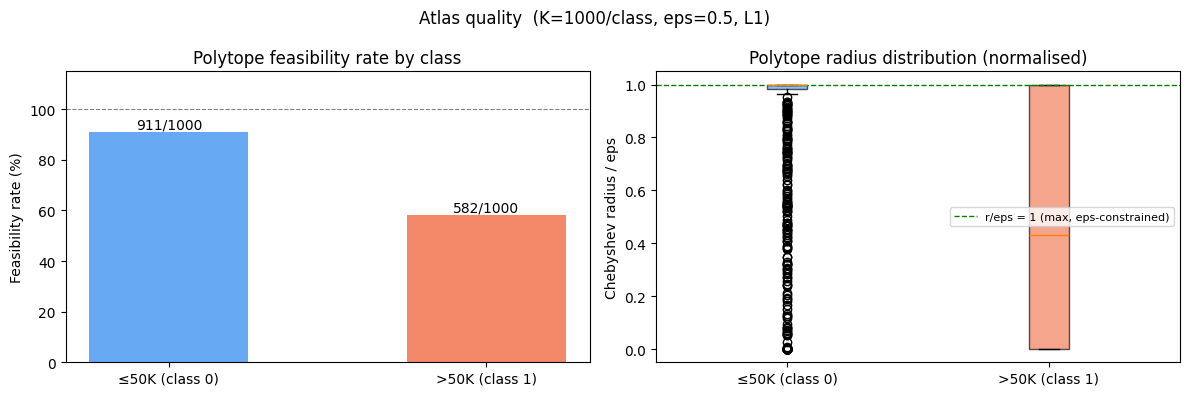

In [15]:
# 10b. Visualisation: feasibility bar + Chebyshev radius / eps distribution
cls_colors = {0: '#4e9af1', 1: '#f1754e'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Feasibility bar ---
ax = axes[0]
for cls in [0, 1]:
    n_feas = sum(all_feasible[cls])
    n_tot  = len(all_feasible[cls])
    ax.bar(cls, 100 * n_feas / n_tot, width=0.5,
           color=cls_colors[cls], alpha=0.85, label=cls_labels[cls])
    ax.text(cls, 100 * n_feas / n_tot + 1.5,
            f'{n_feas}/{n_tot}', ha='center', fontsize=10)
ax.set_xticks([0, 1])
ax.set_xticklabels([cls_labels[0], cls_labels[1]])
ax.set_ylabel('Feasibility rate (%)')
ax.set_ylim(0, 115)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Polytope feasibility rate by class')

# --- Chebyshev radius / eps boxplot ---
ax = axes[1]
data_box = [np.array(all_radii[cls]) / atlas.eps for cls in [0, 1]]
bp = ax.boxplot(data_box, labels=[cls_labels[0], cls_labels[1]],
                patch_artist=True, notch=False, showfliers=True)
for patch, cls in zip(bp['boxes'], [0, 1]):
    patch.set_facecolor(cls_colors[cls])
    patch.set_alpha(0.65)
ax.axhline(1.0, color='green', linestyle='--', linewidth=1,
           label='r/eps = 1 (max, eps-constrained)')
ax.set_ylabel('Chebyshev radius / eps')
ax.set_title('Polytope radius distribution (normalised)')
ax.legend(fontsize=8)

plt.suptitle(f'Atlas quality  (K={K_PER_CLASS}/class, eps={atlas.eps}, L{atlas.norm})',
             fontsize=12)
plt.tight_layout()
plt.show()


## 11. Batch counterfactuals — multiple queries

Run `find_counterfactual_batch` on **N_QUERIES** test points predicted as class 0,
then collect success rate, L2 distance, feature-level sparsity, and decoded validity.

In [16]:
import time

N_QUERIES = 30
q_indices = (preds_test == 0).nonzero(as_tuple=True)[0][:N_QUERIES].tolist()

with torch.no_grad():
    Z_queries = model.embed(X_test[q_indices].to(DEVICE)).cpu().numpy()

t0 = time.perf_counter()
batch_res = atlas.find_counterfactual_batch(
    Z_queries, target_class=1, method='bvh',
    fixed_dims=fixed_dims, solver_maxiter=3000
)
t1 = time.perf_counter()

metrics_rows = []
for idx, (qi, res, z_q) in enumerate(zip(q_indices, batch_res, Z_queries)):
    x_q = X_test[qi]
    row = {
        'query_idx': int(qi),
        'success': res.success,
        'l2_distance': res.distance,
        'n_qp_solved': res.n_qp_solved,
        'sparsity': np.nan,
        'n_features_changed': np.nan,
        'decoded_valid': False,
    }
    if res.success:
        z_cf_t  = torch.tensor(res.x_cf, dtype=torch.float32).unsqueeze(0)
        x_cf_d  = model.decode(z_cf_t).squeeze(0)
        diff    = (x_cf_d.numpy() - x_q.numpy())
        n_chg   = int(np.sum(np.abs(diff) > 1e-4))
        row['sparsity']          = n_chg / len(_ALL_COLS)
        row['n_features_changed']= n_chg
        with torch.no_grad():
            pred_d = model(x_cf_d.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
        row['decoded_valid'] = (pred_d == 1)
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
n_succ = int(metrics_df['success'].sum())

print(f'Batch CFs  ({N_QUERIES} queries, {t1-t0:.1f}s total, {(t1-t0)/N_QUERIES*1000:.0f}ms/query)')
print(f'  Success rate         : {n_succ}/{N_QUERIES} ({100*n_succ/N_QUERIES:.1f}%)')
print(f'  Decoded valid (class 1): {metrics_df["decoded_valid"].sum()}/{n_succ}')
print(f'  Mean L2 distance     : {metrics_df["l2_distance"].mean():.4f}')
print(f'  Median sparsity      : {metrics_df["sparsity"].median():.2f}  '
      f'(avg {metrics_df["n_features_changed"].mean():.1f}/{len(_ALL_COLS)} features changed)')
print(f'  Median QPs solved    : {metrics_df["n_qp_solved"].median():.0f}')
metrics_df.head(10)


Batch CFs  (30 queries, 9.6s total, 320ms/query)
  Success rate         : 29/30 (96.7%)
  Decoded valid (class 1): 11/29
  Mean L2 distance     : inf
  Median sparsity      : 0.71  (avg 10.2/14 features changed)
  Median QPs solved    : 28


,query_idx,success,l2_distance,n_qp_solved,sparsity,n_features_changed,decoded_valid
0,0,True,4.306037,342,0.785714,11.0,False
1,2,True,0.787211,1,0.642857,9.0,False
2,4,True,1.983112,12,0.785714,11.0,False
3,5,True,2.004382,37,0.857143,12.0,True
4,6,True,3.106367,135,0.785714,11.0,True
5,7,True,0.867626,5,0.714286,10.0,False
6,8,True,1.395186,16,0.714286,10.0,True
7,9,True,1.324318,27,0.714286,10.0,False
8,12,True,0.358814,3,0.571429,8.0,False
9,14,True,1.088683,25,0.785714,11.0,False


## 12. BVH vs exhaustive k-NN efficiency benchmark

Compare:
- **BVH** (`method='bvh'`): branch-and-bound, only evaluates polytopes the query can reach.
- **Exhaustive k-NN** (`method='knn'`, `k=K_PER_CLASS`): tries all K polytopes in order of distance.

Metric: number of QP projections solved and wall-clock time per query.

In [ ]:
N_BENCH = min(20, N_QUERIES)
bench_queries = Z_queries[:N_BENCH]

bvh_qps,  bvh_times  = [], []
knn_qps,  knn_times  = [], []

for z_q in bench_queries:
    t0 = time.perf_counter()
    r_bvh = atlas.find_counterfactual(
        z_q, target_class=1, method='bvh', fixed_dims=fixed_dims)
    bvh_times.append(time.perf_counter() - t0)
    bvh_qps.append(r_bvh.n_qp_solved)

    t0 = time.perf_counter()
    r_knn = atlas.find_counterfactual(
        z_q, target_class=1, method='knn', k=K_PER_CLASS, fixed_dims=fixed_dims)
    knn_times.append(time.perf_counter() - t0)
    knn_qps.append(r_knn.n_qp_solved)

print(f'BVH        : {np.mean(bvh_qps):.1f} QPs/query,  {np.mean(bvh_times)*1000:.1f} ms/query')
print(f'Exhaustive : {np.mean(knn_qps):.1f} QPs/query,  {np.mean(knn_times)*1000:.1f} ms/query')
print(f'QP reduction : {np.mean(knn_qps)/np.mean(bvh_qps):.1f}x  |  '
      f'Speedup : {np.mean(knn_times)/np.mean(bvh_times):.1f}x')


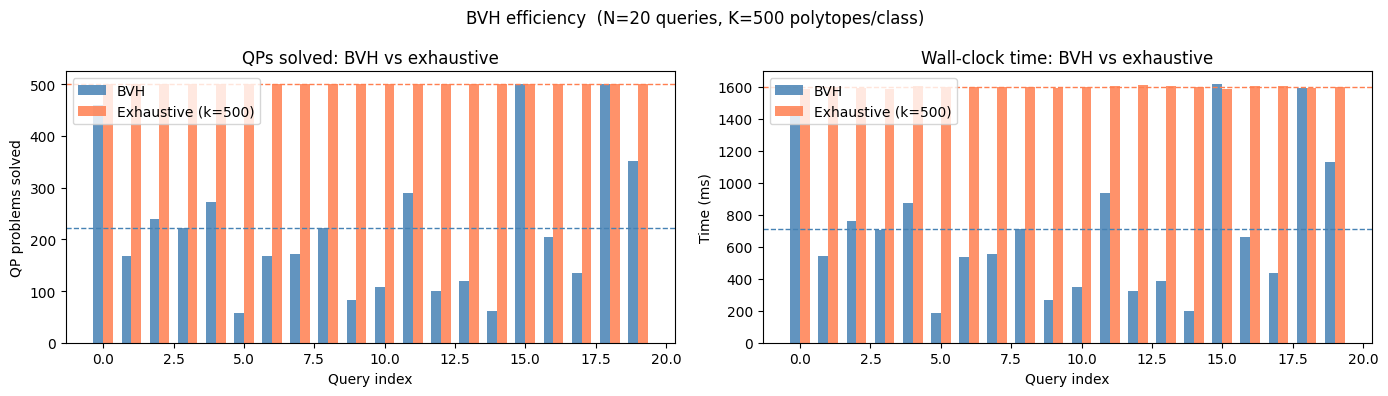

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x_ax = np.arange(N_BENCH)
w = 0.35

ax = axes[0]
ax.bar(x_ax - w/2, bvh_qps, width=w, label='BVH',
       color='steelblue', alpha=0.85)
ax.bar(x_ax + w/2, knn_qps, width=w, label=f'Exhaustive (k={K_PER_CLASS})',
       color='coral', alpha=0.85)
ax.axhline(np.mean(bvh_qps), color='steelblue', linestyle='--', linewidth=1)
ax.axhline(np.mean(knn_qps), color='coral',     linestyle='--', linewidth=1)
ax.set_xlabel('Query index'); ax.set_ylabel('QP problems solved')
ax.set_title('QPs solved: BVH vs exhaustive')
ax.legend()

ax = axes[1]
ax.bar(x_ax - w/2, np.array(bvh_times)*1000, width=w, label='BVH',
       color='steelblue', alpha=0.85)
ax.bar(x_ax + w/2, np.array(knn_times)*1000, width=w,
       label=f'Exhaustive (k={K_PER_CLASS})', color='coral', alpha=0.85)
ax.axhline(np.mean(bvh_times)*1000, color='steelblue', linestyle='--', linewidth=1)
ax.axhline(np.mean(knn_times)*1000, color='coral',     linestyle='--', linewidth=1)
ax.set_xlabel('Query index'); ax.set_ylabel('Time (ms)')
ax.set_title('Wall-clock time: BVH vs exhaustive')
ax.legend()

plt.suptitle(f'BVH efficiency  (N={N_BENCH} queries, K={K_PER_CLASS} polytopes/class)',
             fontsize=12)
plt.tight_layout()
plt.show()


## 13. Counterfactual quality metrics

For each successful CF we compute:
| Metric | Description |
|--------|-------------|
| **L2 distance** | `‖z_cf − z_query‖₂` in embedding space |
| **Sparsity** | fraction of the 14 features that changed |
| **LOF plausibility** | Local Outlier Factor vs target-class training embeddings (lower = more plausible) |
| **QPs solved** | number of QP projections by BVH (efficiency proxy) |

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Fit LOF on class-1 (>50K) training embeddings
Z1_train = Z_train[(y_train == 1).numpy()].numpy()
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(Z1_train)

succ_mask    = metrics_df['success'].values
succ_indices = np.where(succ_mask)[0]

lof_scores = np.full(len(metrics_df), np.nan)
for i in succ_indices:
    lof_scores[i] = -lof.score_samples(batch_res[i].x_cf.reshape(1, -1))[0]

metrics_df['lof_score'] = lof_scores

succ_df = metrics_df[metrics_df['success']]
print(f'Quality metrics  (n={len(succ_df)} successful CFs):')
cols_desc = [
    ('l2_distance',        'L2 distance (embedding space)'),
    ('n_features_changed', 'N features changed (out of 14)'),
    ('sparsity',           'Sparsity (fraction features changed)'),
    ('lof_score',          'LOF score (lower = more plausible)'),
    ('n_qp_solved',        'QPs solved (BVH efficiency)'),
]
for col, desc in cols_desc:
    v = succ_df[col].dropna()
    print(f'  {desc:<42s}: mean={v.mean():.3f}  median={v.median():.3f}  std={v.std():.3f}')


Quality metrics  (n=28 successful CFs):
  L2 distance (embedding space)             : mean=2.087  median=1.654  std=1.223
  N features changed (out of 14)            : mean=5.429  median=5.000  std=1.526
  Sparsity (fraction features changed)      : mean=0.388  median=0.357  std=0.109
  LOF score (lower = more plausible)        : mean=1.112  median=1.061  std=0.164
  QPs solved (BVH efficiency)               : mean=199.250  median=170.000  std=115.215


/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


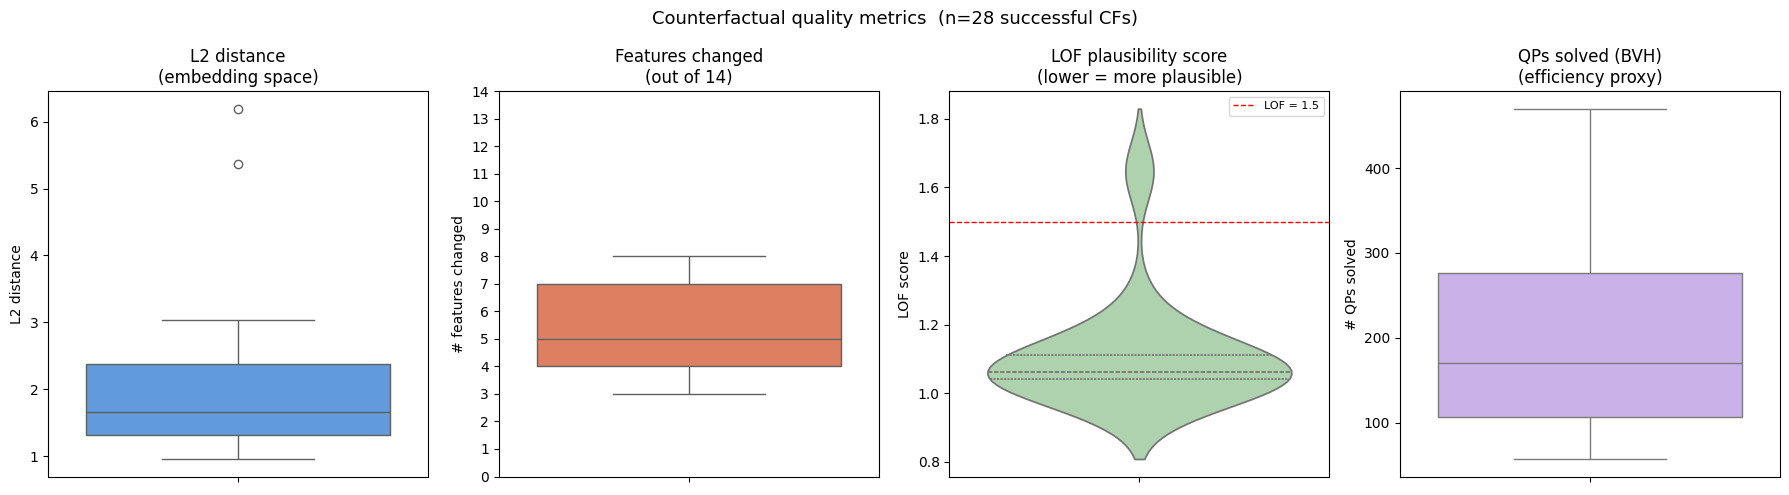

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
succ_df = metrics_df[metrics_df['success']].copy()

sns.boxplot(y=succ_df['l2_distance'], ax=axes[0], color='#4e9af1')
axes[0].set_title('L2 distance\n(embedding space)')
axes[0].set_ylabel('L2 distance')

sns.boxplot(y=succ_df['n_features_changed'], ax=axes[1], color='#f1754e')
axes[1].set_title('Features changed\n(out of 14)')
axes[1].set_ylabel('# features changed')
axes[1].set_yticks(range(0, 15))

sns.violinplot(y=succ_df['lof_score'], ax=axes[2], color='#a8d8a8', inner='quart')
axes[2].axhline(1.5, color='red', linestyle='--', linewidth=1, label='LOF = 1.5')
axes[2].set_title('LOF plausibility score\n(lower = more plausible)')
axes[2].set_ylabel('LOF score')
axes[2].legend(fontsize=8)

sns.boxplot(y=succ_df['n_qp_solved'], ax=axes[3], color='#c9a8f1')
axes[3].set_title('QPs solved (BVH)\n(efficiency proxy)')
axes[3].set_ylabel('# QPs solved')

plt.suptitle(f'Counterfactual quality metrics  (n={len(succ_df)} successful CFs)', fontsize=13)
plt.tight_layout()
plt.show()


## 14. Feature-level change analysis

Across all successful CFs (decoded to original feature space):
- **Change frequency**: how often each feature is modified.
- **Mean absolute delta**: average magnitude of change for numerical features (in scaled space).

Fixed features (`race`, `sex`, `native-country`) should show 0% change by construction.

In [ ]:
change_records = []
for i in succ_indices:
    res  = batch_res[i]
    x_q  = X_test[q_indices[i]]
    z_cf_t  = torch.tensor(res.x_cf, dtype=torch.float32).unsqueeze(0)
    x_cf_d  = model.decode(z_cf_t).squeeze(0)

    orig = to_human_readable(x_q.cpu(), dm)
    cf   = to_human_readable(x_cf_d.cpu(), dm)

    row = {'query_i': int(i)}
    for col, t in zip(_ALL_COLS, INPUT_TYPES):
        row[f'chg_{col}'] = (orig[col] != cf[col])
        if t == 'numerical':
            row[f'delta_{col}'] = cf[col] - orig[col]
    change_records.append(row)

change_df = pd.DataFrame(change_records)

change_rate = pd.Series(
    {col: change_df[f'chg_{col}'].mean() for col in _ALL_COLS},
    name='change_rate'
).sort_values(ascending=False)

print('Feature change frequency across successful CFs:')
for col, rate in change_rate.items():
    bar   = '#' * int(rate * 30)
    fixed = ' [FIXED]' if col in FIXED_FEATURES else ''
    print(f'  {col:<20s} {rate:5.1%}  {bar}{fixed}')


Feature change frequency across successful CFs:
  fnlwgt               100.0%  ##############################
  capital-gain         100.0%  ##############################
  occupation           78.6%  #######################
  hours-per-week       60.7%  ##################
  education-num        53.6%  ################
  education            53.6%  ################
  workclass            42.9%  ############
  marital-status       28.6%  ########
  relationship         25.0%  #######
  age                   0.0%   [FIXED]
  sex                   0.0%   [FIXED]
  race                  0.0%   [FIXED]
  capital-loss          0.0%  
  native-country        0.0%   [FIXED]


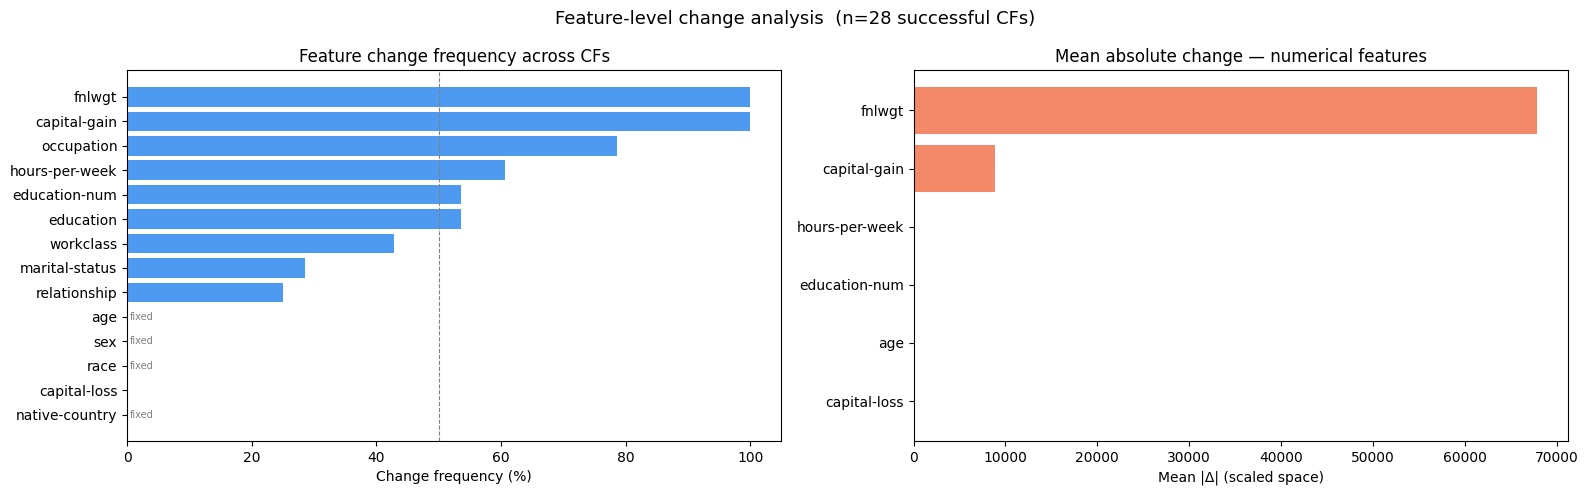

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Change frequency ---
ax = axes[0]
bar_colors = ['#aaa' if col in FIXED_FEATURES else '#4e9af1'
              for col in change_rate.index]
ax.barh(change_rate.index, change_rate.values * 100, color=bar_colors)
ax.set_xlabel('Change frequency (%)')
ax.set_title('Feature change frequency across CFs')
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8)
for col in FIXED_FEATURES:
    if col in change_rate.index:
        idx = list(change_rate.index).index(col)
        ax.annotate('fixed', xy=(change_rate[col]*100 + 0.5, idx),
                    fontsize=7, color='gray', va='center')
ax.invert_yaxis()

# --- Mean absolute delta (numerical features) ---
ax = axes[1]
num_cols_present = [c for c in _ALL_COLS
                    if c in _NUMERICAL and f'delta_{c}' in change_df.columns]
mean_delta = pd.Series(
    {c: change_df[f'delta_{c}'].abs().mean() for c in num_cols_present},
    name='mean_abs_delta'
).sort_values(ascending=False)
ax.barh(mean_delta.index, mean_delta.values, color='#f1754e', alpha=0.85)
ax.set_xlabel('Mean |Δ| (scaled space)')
ax.set_title('Mean absolute change — numerical features')
ax.invert_yaxis()

plt.suptitle(f'Feature-level change analysis  (n={len(change_df)} successful CFs)', fontsize=13)
plt.tight_layout()
plt.show()


## 15. Delta-robust counterfactuals

Setting `delta > 0` erodes each certified polytope inward so that the entire
`B_q(x_cf, delta)` ball lies within the original certified region — guaranteeing
the CF remains classified as class 1 under any perturbation of radius `delta`.

We sweep `delta` over a range and measure:
- **Success rate**: fraction of queries that still find a CF (erosion can make polytopes infeasible).
- **Distance penalty**: how much farther the robust CF is compared to `delta = 0`.

In [ ]:
delta_values = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30]

# Single-query sweep (for visual inspection of the CF at each delta)
delta_single = []
for delta in delta_values:
    res = atlas.find_counterfactual(
        z_query, target_class=1, method='bvh',
        fixed_dims=fixed_dims, delta=delta, solver_maxiter=3000
    )
    delta_single.append({
        'delta': delta, 'success': res.success,
        'distance': res.distance, 'n_qp_solved': res.n_qp_solved,
    })
delta_single_df = pd.DataFrame(delta_single)
print('Single-query delta sweep:')
print(delta_single_df.to_string(index=False, float_format='{:.4f}'.format))


Single-query delta sweep:
 delta  success  distance  n_qp_solved
0.0000     True    5.3689          460
0.0100     True    5.3755          461
0.0200     True    5.3821          461
0.0500     True    5.4020          461
0.1000     True    5.4354          462
0.2000    False       inf          500
0.3000    False       inf          500


In [ ]:
# Batch sweep: N_DELTA_QUERIES queries for reliable statistics
N_DELTA_QUERIES = min(20, N_QUERIES)
batch_delta_queries = Z_queries[:N_DELTA_QUERIES]

delta_summary = []
for delta in delta_values:
    res_list = atlas.find_counterfactual_batch(
        batch_delta_queries, target_class=1, method='bvh',
        fixed_dims=fixed_dims, delta=delta, solver_maxiter=3000
    )
    succ = [r for r in res_list if r.success]
    delta_summary.append({
        'delta': delta,
        'success_rate': len(succ) / len(res_list),
        'mean_dist':   float(np.mean([r.distance for r in succ])) if succ else np.nan,
        'median_dist': float(np.median([r.distance for r in succ])) if succ else np.nan,
    })

delta_df = pd.DataFrame(delta_summary)
print(f'Batch delta sweep  (N={N_DELTA_QUERIES} queries):')
print(delta_df.to_string(index=False, float_format='{:.4f}'.format))


/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/atoms/quad_over_lin.py:43: RuntimeWarning: overflow encountered in square
  return np.square(values[0]).sum()/values[1]


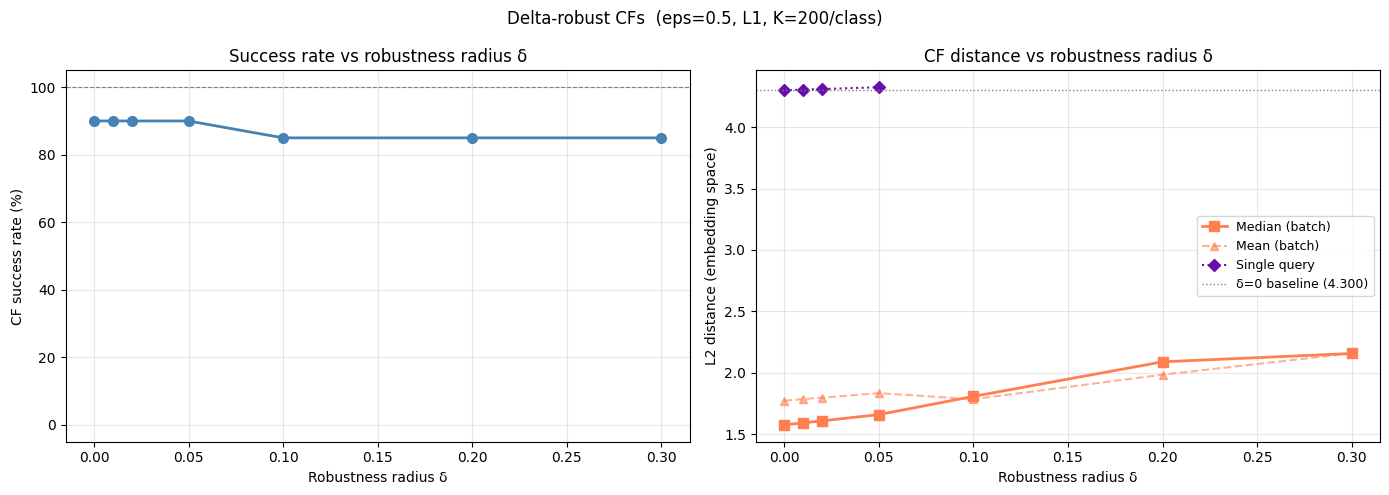

In [ ]:
dist_baseline = delta_single_df.loc[
    delta_single_df['delta'] == 0.0, 'distance'].values[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Success rate vs delta
ax = axes[0]
ax.plot(delta_df['delta'], delta_df['success_rate'] * 100,
        'o-', color='steelblue', linewidth=2, markersize=7)
ax.set_xlabel('Robustness radius δ')
ax.set_ylabel('CF success rate (%)')
ax.set_title('Success rate vs robustness radius δ')
ax.set_ylim(-5, 105)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)

# Distance vs delta
ax = axes[1]
ax.plot(delta_df['delta'], delta_df['median_dist'],
        's-', color='coral', linewidth=2, markersize=7, label='Median (batch)')
ax.plot(delta_df['delta'], delta_df['mean_dist'],
        '^--', color='coral', linewidth=1.5, alpha=0.6, label='Mean (batch)')
ax.plot(delta_single_df['delta'], delta_single_df['distance'],
        'D:', color='#6a0dad', linewidth=1.5, markersize=6, label='Single query')
ax.axhline(dist_baseline, color='gray', linestyle=':', linewidth=1,
           label=f'δ=0 baseline ({dist_baseline:.3f})')
ax.set_xlabel('Robustness radius δ')
ax.set_ylabel('L2 distance (embedding space)')
ax.set_title('CF distance vs robustness radius δ')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Delta-robust CFs  (eps={atlas.eps}, L{atlas.norm}, K={K_PER_CLASS}/class)',
             fontsize=12)
plt.tight_layout()
plt.show()
